In [4]:
import numpy as np
import pandas as pd

# ==============================================================================
# 1. LOAD RAW DATASET
# ==============================================================================
csv_path = r"F:\ASC 23-27\Sem 7\Business Analytics\Case Study\Final cs\AgriProcure\AgriProcure\data\preprocessed dataset.csv"
raw_df = pd.read_csv(csv_path)
initial_rows = len(raw_df)
print(f"Loaded raw dataset with shape: {raw_df.shape}")

# ==============================================================================
# 2. STRING CLEANING & STANDARDIZATION
# ==============================================================================
str_cols = ["crop", "state", "district", "market_name"]
for col in str_cols:
    if col in raw_df.columns:
        raw_df[col] = (
            raw_df[col]
            .astype(str)
            .str.strip()
            .str.title()
            .str.replace(r"[^\w\s]", "", regex=True)
        )

# Standardize near-duplicate or aliased mandi names
market_aliases = {
    "Bengaluru South": "Bangalore",
    "Bengaluru City": "Bangalore",
    "Bombay": "Mumbai",
}
raw_df["market_name"] = raw_df["market_name"].replace(market_aliases)

# Parse Dates (drop unparseable rows)
raw_df["date"] = pd.to_datetime(raw_df["date"], errors="coerce")
raw_df = raw_df.dropna(subset=["date"]).copy()

# ==============================================================================
# 3. DEDUPLICATION (Slide 4 Audit Alignment)
# ==============================================================================
# Drop redundant ETL pipeline metadata before dedup
drop_cols = ["fetched_at", "in_shortlist", "source"]
clean_df = raw_df.drop(
    columns=[c for c in drop_cols if c in raw_df.columns]
).copy()

dedup_subset = ["date", "market_name", "crop"]
clean_df = clean_df.drop_duplicates(subset=dedup_subset, keep="last").copy()
print(
    f"Deduplication complete: {initial_rows:,} -> {len(clean_df):,} rows "
    f"(dropped {initial_rows - len(clean_df):,} duplicates)."
)

# Convert strings to categories for memory efficiency
for col in str_cols:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].astype("category")

# ==============================================================================
# 4. MISSING VALUE IMPUTATION (Mandi x Crop Median — Run BEFORE filtering)
# ==============================================================================
# If a specific (mandi, crop) combination is entirely NaN, fall back to crop median
def impute_grouped_median(df, value_col):
    mandi_crop_median = df.groupby(["market_name", "crop"], observed=True)[
        value_col
    ].transform("median")
    crop_median = df.groupby("crop", observed=True)[value_col].transform("median")
    return df[value_col].fillna(mandi_crop_median).fillna(crop_median)


clean_df["modal_price_rs_quintal"] = impute_grouped_median(
    clean_df, "modal_price_rs_quintal"
)
clean_df["arrivals_tonnes"] = impute_grouped_median(
    clean_df, "arrivals_tonnes"
)

# Backfill min/max price relative to modal price if missing
clean_df["min_price_rs_quintal"] = clean_df["min_price_rs_quintal"].fillna(
    clean_df["modal_price_rs_quintal"]
)
clean_df["max_price_rs_quintal"] = clean_df["max_price_rs_quintal"].fillna(
    clean_df["modal_price_rs_quintal"]
)

# ==============================================================================
# 5. DOMAIN INTEGRITY FILTERS
# ==============================================================================
clean_df = clean_df[
    (clean_df["min_price_rs_quintal"] <= clean_df["modal_price_rs_quintal"])
    & (clean_df["modal_price_rs_quintal"] <= clean_df["max_price_rs_quintal"])
    & (clean_df["arrivals_tonnes"] > 0)
].copy()

clean_df["price_spread"] = (
    clean_df["max_price_rs_quintal"] - clean_df["min_price_rs_quintal"]
)

# ==============================================================================
# 6. OUTLIER AUDIT VIA IQR (Per Mandi x Crop)
# ==============================================================================
def flag_outliers_iqr(df, col, group_cols=["market_name", "crop"], multiplier=1.5):
    """Calculates granular IQR bounds; falls back to crop-level if group IQR is 0."""
    grouped = df.groupby(group_cols, observed=True)[col]
    q1 = grouped.transform("quantile", 0.25)
    q3 = grouped.transform("quantile", 0.75)
    iqr = q3 - q1

    # Fallback to broader crop IQR if a mandi has too few observations
    zero_iqr_mask = iqr == 0
    if zero_iqr_mask.any():
        crop_grouped = df.groupby("crop", observed=True)[col]
        q1_crop = crop_grouped.transform("quantile", 0.25)
        q3_crop = crop_grouped.transform("quantile", 0.75)
        iqr_crop = q3_crop - q1_crop
        q1 = q1.mask(zero_iqr_mask, q1_crop)
        q3 = q3.mask(zero_iqr_mask, q3_crop)
        iqr = iqr.mask(zero_iqr_mask, iqr_crop)

    lower = q1 - (multiplier * iqr)
    upper = q3 + (multiplier * iqr)
    return (df[col] < lower) | (df[col] > upper)


clean_df["is_price_spread_outlier"] = flag_outliers_iqr(clean_df, "price_spread")
clean_df["is_arrival_outlier"] = flag_outliers_iqr(clean_df, "arrivals_tonnes")

print(f"Flagged price spread anomalies: {clean_df['is_price_spread_outlier'].sum():,}")
print(f"Flagged arrival shock events:   {clean_df['is_arrival_outlier'].sum():,}")

# ==============================================================================
# 7. SUBSET TARGET CROPS & CONSTRUCT WEEKLY PANEL
# ==============================================================================
target_crops = ["Tomato", "Onion", "Potato"]
top_crops_df = clean_df[clean_df["crop"].isin(target_crops)].copy()
top_crops_df["crop"] = top_crops_df["crop"].cat.remove_unused_categories()

# Assign Monday of the calendar week
top_crops_df["week_start_date"] = (
    top_crops_df["date"]
    - pd.to_timedelta(top_crops_df["date"].dt.dayofweek, unit="D")
)

weekly_panel = (
    top_crops_df.groupby(
        ["crop", "state", "district", "market_name", "week_start_date"],
        observed=True,
    )
    .agg(
        weekly_modal_price=("modal_price_rs_quintal", "mean"),
        weekly_min_price=("min_price_rs_quintal", "min"),
        weekly_max_price=("max_price_rs_quintal", "max"),
        weekly_total_arrivals=("arrivals_tonnes", "sum"),
        weekly_avg_daily_arrivals=("arrivals_tonnes", "mean"),
        trading_days_active=("date", "count"),
        spread_shock_days=("is_price_spread_outlier", "sum"),
        arrival_shock_days=("is_arrival_outlier", "sum"),
    )
    .reset_index()
)

# Standardize rounding for presentation & reporting
weekly_panel["weekly_modal_price"] = weekly_panel["weekly_modal_price"].round(2)
weekly_panel["weekly_min_price"] = weekly_panel["weekly_min_price"].round(2)
weekly_panel["weekly_max_price"] = weekly_panel["weekly_max_price"].round(2)
weekly_panel["weekly_total_arrivals"] = weekly_panel["weekly_total_arrivals"].round(2)
weekly_panel["weekly_avg_daily_arrivals"] = weekly_panel["weekly_avg_daily_arrivals"].round(2)

print(
    f"Constructed weekly panel: {weekly_panel.shape[0]:,} rows across "
    f"{weekly_panel['market_name'].nunique()} mandis."
)



Loaded raw dataset with shape: (241780, 12)
Deduplication complete: 241,780 -> 241,780 rows (dropped 0 duplicates).
Flagged price spread anomalies: 599
Flagged arrival shock events:   0
Constructed weekly panel: 11,130 rows across 70 mandis.


C:\Users\aathi\AppData\Local\Temp\ipykernel_28204\3941942266.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\aathi\AppData\Local\Temp\ipykernel_28204\3941942266.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


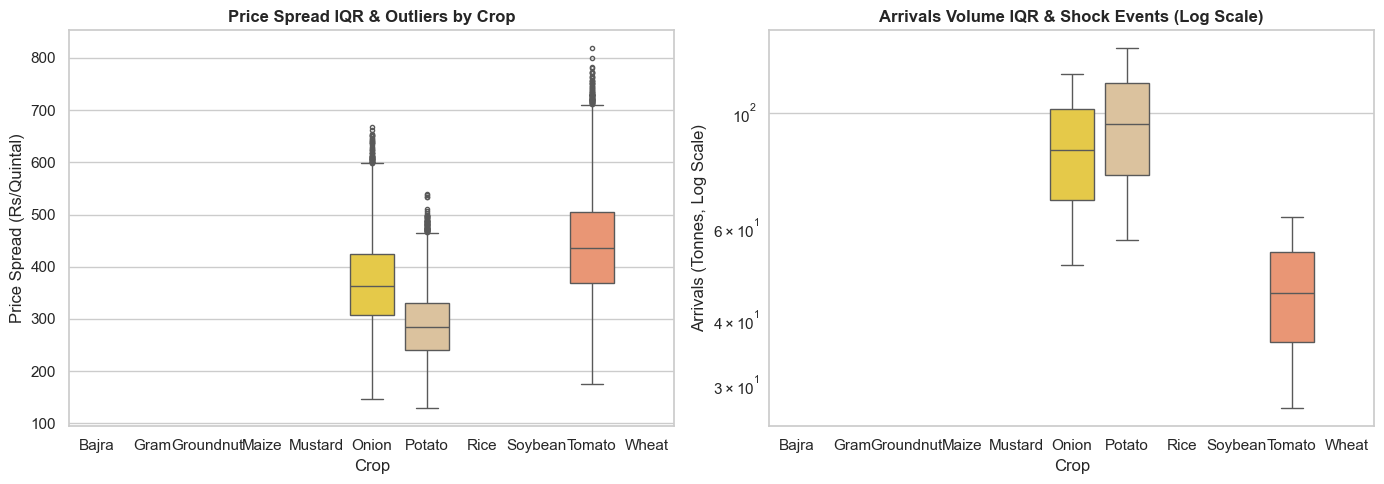

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Price Spread Boxplot per Crop
sns.boxplot(
    data=clean_df[clean_df["crop"].isin(["Tomato", "Onion", "Potato"])],
    x="crop",
    y="price_spread",
    ax=axes[0],
    palette="Set2",
    fliersize=3,
)
axes[0].set_title(
    "Price Spread IQR & Outliers by Crop", fontsize=12, fontweight="bold"
)
axes[0].set_ylabel("Price Spread (Rs/Quintal)")
axes[0].set_xlabel("Crop")

# 2. Daily Arrivals Boxplot per Crop (Log scale helps if volumes vary by orders of magnitude)
sns.boxplot(
    data=clean_df[clean_df["crop"].isin(["Tomato", "Onion", "Potato"])],
    x="crop",
    y="arrivals_tonnes",
    ax=axes[1],
    palette="Set2",
    fliersize=3,
)
axes[1].set_yscale("log")
axes[1].set_title(
    "Arrivals Volume IQR & Shock Events (Log Scale)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_ylabel("Arrivals (Tonnes, Log Scale)")
axes[1].set_xlabel("Crop")

plt.tight_layout()
plt.show()